# 1. DATA EXPLORATION AND PREPROCESSING

In [ ]:
import pandas as pd
df = pd.read_excel('Airbnb_data.xlsx')
print(df.shape)
df.head()

(74111, 29)


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


<Axes: xlabel='log_price'>

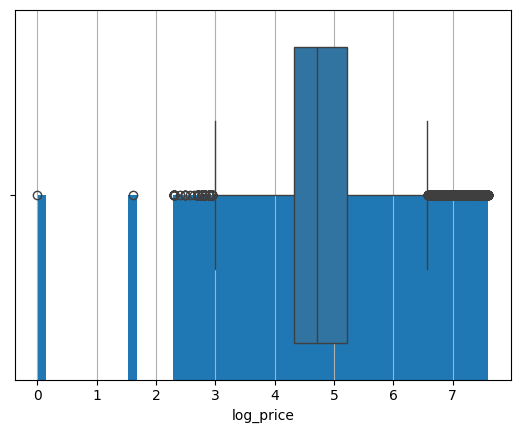

In [ ]:
df.describe()
df['log_price'].hist(bins=50)
df.isnull().sum()
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=df['log_price'])

In [ ]:
df = df.drop(columns=['host_response_rate', 'first_review', 'thumbnail_url', 'last_review', 'description', 'amenities'])
df = df.dropna()
df = df[['log_price','property_type','room_type','accommodates','bathrooms',
         'bed_type','cancellation_policy','cleaning_fee','city','bedrooms','beds']]
print("Remaining columns:", df.columns.tolist())
print("Remaining rows:", len(df))

Remaining columns: ['log_price', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'bedrooms', 'beds']
Remaining rows: 51545


In [ ]:
df = pd.get_dummies(df, drop_first=True)
df = df.reset_index(drop=True)

print("DataFrame shape after encoding:", df.shape)
df.head(2)  # Show first 2 rows only

DataFrame shape after encoding: (51545, 51)


,log_price,accommodates,bathrooms,cleaning_fee,bedrooms,beds,property_type_Bed & Breakfast,property_type_Boat,property_type_Boutique hotel,property_type_Bungalow,...,bed_type_Real Bed,cancellation_policy_moderate,cancellation_policy_strict,cancellation_policy_super_strict_30,cancellation_policy_super_strict_60,city_Chicago,city_DC,city_LA,city_NYC,city_SF
0,5.010635,3,1.0,True,1.0,1.0,False,False,False,False,...,True,False,True,False,False,False,False,False,True,False
1,5.129899,7,1.0,True,3.0,3.0,False,False,False,False,...,True,False,True,False,False,False,False,False,True,False


In [ ]:
X = df.drop('log_price', axis=1)
y = df['log_price']

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

Shape of X (features): (51545, 50)
Shape of y (target): (51545,)


In [ ]:
X = pd.get_dummies(X, drop_first=True)

print("Shape of X after encoding:", X.shape)

Shape of X after encoding: (51545, 50)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (41236, 50)
X_test shape: (10309, 50)
y_train shape: (41236,)
y_test shape: (10309,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data mean (first 5 features):", X_train_scaled.mean(axis=0)[:5])
print("Scaled training data std (first 5 features):", X_train_scaled.std(axis=0)[:5])

Scaled training data mean (first 5 features): [ 4.81179210e-17  1.45689175e-16 -1.04162160e-16 -2.71390244e-18
 -4.75148316e-17]
Scaled training data std (first 5 features): [1. 1. 1. 1. 1.]


# 2. MODEL DEVELOPMENT


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Number of model coefficients:", len(model.coef_))
print("First 5 coefficients:", model.coef_[:5])

Number of model coefficients: 50
First 5 coefficients: [ 0.15834979  0.08681548  0.00329971  0.12553362 -0.05432044]


# 3. MODEL EVALUATION

RMSE: 0.418
MAE: 0.322
R² Score: 0.598


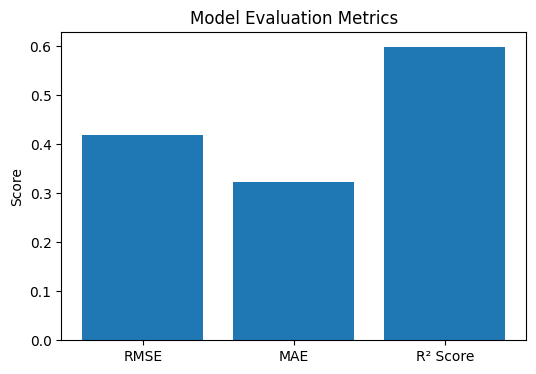

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print Results
print("RMSE:", round(rmse, 3))
print("MAE:", round(mae, 3))
print("R² Score:", round(r2, 3))

# Bar Chart
metrics = ['RMSE', 'MAE', 'R² Score']
values = [rmse, mae, r2]

plt.figure(figsize=(6, 4))
plt.bar(metrics, values)
plt.title("Model Evaluation Metrics")
plt.ylabel("Score")
plt.show()

Google Drive Link to project Video Explanation, Presentation , and Code Files: https://drive.google.com/drive/folders/1ev3ABZfVt1-Noy_bMUXaUK-82nHUplO3?usp=sharing